In [1]:
import seaborn as sns
df=sns.load_dataset("iris")
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


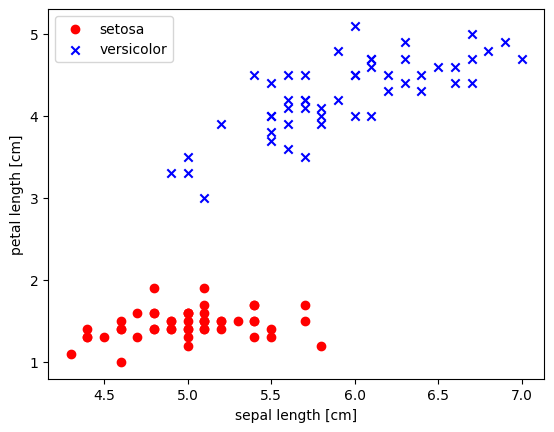

In [5]:
import matplotlib.pyplot as plt
import numpy as np
#1-100行目の目的変数の抽出
y=df.iloc[0:100, 4].values
#setosaを-1, versicolorを1に変換
y=np.where(y=="setosa",-1,1)
#1-100行目の1,3列目の抽出
X=df.iloc[0:100, [0,2]].values
#品種setosaのプロット(赤丸)
plt.scatter(X[:50,0] ,X[:50,1], color="red", marker="o", label="setosa")
#品種versicolorのプロット(青バツ)
plt.scatter(X[50:100,0], X[50:100,1], color="blue", marker="x", label="versicolor")
#軸ラベルの設定
plt.xlabel("sepal length [cm]")
plt.ylabel("petal length [cm]")
#凡例の設定
plt.legend(loc="upper left")
#図の表示
plt.show()

In [6]:
import numpy as np

class Perceptron(object):
    """ パーセプトロンの分類機

    パラメータ
    --------------
    eta : float
        学習率(0.0<η<=1.0)
    n_iter : int
        訓練データの訓練回数
    random_state : int
        重みを初期化するための乱数シード

    属性
    ---------------
    w_ : 1次元入れる
        適用後の重み
    errors : リスト
        書くエポックでの誤分類(更新)の数

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta=eta
        self.n_iter=n_iter
        self.random_state=random_state

    def fit(self, X, y):
        """訓練データに適合させる

        パラメータ
        X : {配列のようなデータ構造}, shape= [n_examples, n_features]
            訓練データ
        n_exampleは訓練データの個数、n_featuresは特徴量の個数
        y : {配列のようなデータ構造}, shape=[n_examples]
            目的変数
        
        戻り値
        self : object

        """
        rgen=np.random.RandomState(self.random_state)
        self.w_=rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_=[]

        for _ in range(self.n_iter):
            errors=0
            for xi, target in zip(X,y):
                #重み W1~Wmの更新
                update=self.eta*(target-self.predict(xi))
                self.w_[1:]+=update*xi
                #重み W0の更新
                self.w_[0]+=update
                #重みの更新が0出ない場合は誤分類としてカウント
                errors+=int(update !=0.0)
            #反復ごとの誤差を格納
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """総入力を計算"""
        return np.dot(X, self.w_[1:]) +self.w_[0]

    def predict(self, X):
        """1ステップ後のクラスラベルを返す"""
        return np.where(self.net_input(X)>=0.0,1,-1)

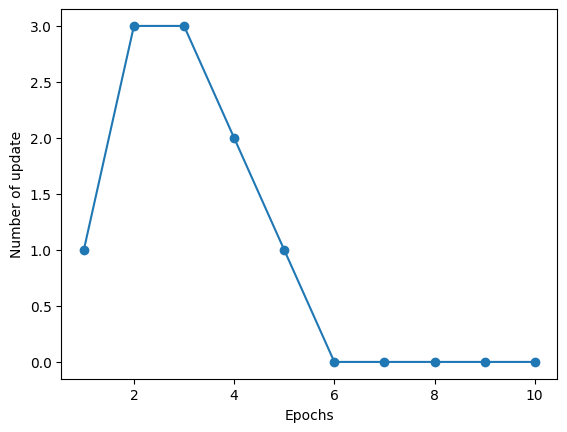

In [8]:
#パーセプトロンのオブジェクトの生成(インスタンス化)
ppn=Perceptron(eta=0.1, n_iter=10)
#訓練データへのモデル適合
ppn.fit(X,y)
#エポックと誤分類の関係を表す折れ線グラフをプロット
plt.plot(range(1, len(ppn.errors_)+1), ppn.errors_, marker="o")
#軸ラベルの設定
plt.xlabel("Epochs")
plt.ylabel("Number of update")
#図の表示
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap

#分類において特徴量2個の場合に可視化できる関数
def plot_decision_regions(X, y, classifier, resolution=0.02):
    #マーカーとカラーマップの準備
    markers=("s", "x", "o", "^", "V")
    colors=("red", "blue", "lightgreen", "gray", "cyan")
    cmap=ListedColormap(colors[:len(np.unique(y))])

    #決定領域のプロット
    x1_min, x1_max=X[:, 0].min()-1, X[:,0].max()+1
    x2_min, x2_max=X[:, 1].min()-1, X[:,1].max()+1

    #グリッドポイントの生成
    xx1, xx2=np.meshgrid(np.arange(x1_min, x1_max, resolution),
                         np.arange(x2_min, x2_max, resolution))

    #各特徴量を1次元配列に変換して予測を実行
    Z=classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    #予測結果をもとのグリッドポイントのデータサイズに変換
    Z=Z.reshape(xx1.shape)
    #グリッドポイントの等高線のプロット
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    #軸の範囲の固定
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    #クラスごとに訓練データをプロット
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y==cl, 0],
                    y=X[y==cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor="black")


/tmp/ipykernel_2775/471257124.py:29: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y==cl, 0],


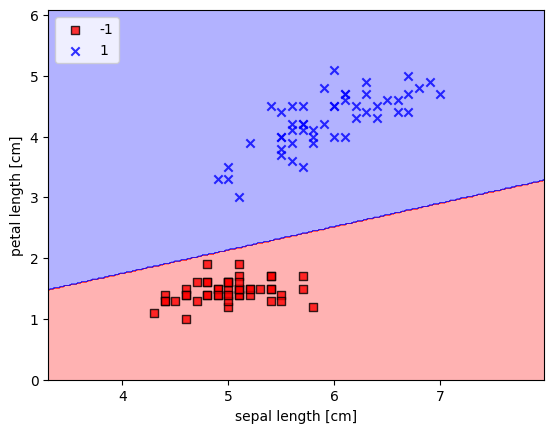

In [11]:
#決定領域のプロット
plot_decision_regions(X, y, classifier=ppn)
#軸ラベルの設定
plt.xlabel("sepal length [cm]")
plt.ylabel("petal length [cm]")
#凡例の設定(左上に配置)
plt.legend(loc="upper left")
#図の表示
plt.show()